<a href="https://colab.research.google.com/github/khushikayy/placement_ml_code/blob/main/placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/placement.csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

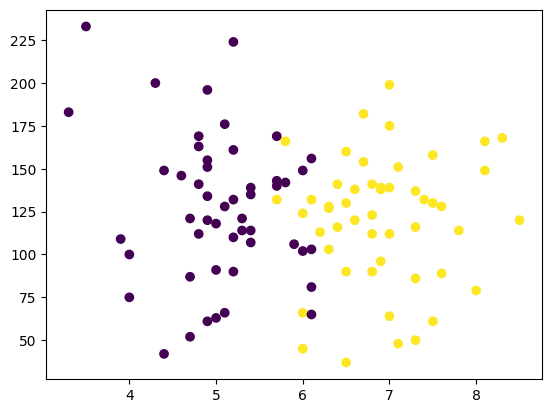

In [9]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [10]:
x = df.iloc[:,0:2]
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [11]:
y = df.iloc[:,-1]
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [13]:
x_train
x_test
y_train
y_test

,placement
95,0
66,1
37,1
14,0
78,0
25,0
67,0
4,0
44,1
75,0


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-0.17154843,  1.0642672 ],
       [-0.70089787,  2.52931856],
       [ 0.44602592,  0.91271016],
       [ 0.62247573,  0.76115312],
       [-0.96557259,  0.78641263],
       [-1.14202241, -1.81531651],
       [ 1.76939952, -1.13330985],
       [-1.0537975 , -0.29974614],
       [-0.52444806,  0.2812225 ],
       [ 0.88715045,  1.29160275],
       [-0.87734768, -1.53746195],
       [ 0.97537536, -1.91635454],
       [ 0.71070064,  0.43277954],
       [ 0.53425082,  0.35700102],
       [-0.70089787, -0.85545528],
       [ 0.00490138, -1.99213306],
       [ 0.88715045,  0.38226053],
       [ 0.88715045, -0.29974614],
       [ 1.15182517,  0.33174152],
       [ 0.09312629,  0.81167213],
       [-0.52444806,  0.38226053],
       [ 1.15182517, -0.9564933 ],
       [-0.96557259, -0.09767009],
       [-2.20072129,  2.75665411],
       [-0.78912278,  0.10440596],
       [-0.70089787,  0.20544398],
       [ 0.2695761 , -0.5270817 ],
       [-1.14202241, -0.07241058],
       [ 1.41649989,

In [17]:
x_test = scaler.transform(x_test)
x_test

array([[-1.49492203,  1.92309041],
       [ 0.79892555, -0.70389824],
       [ 1.85762443,  0.63485559],
       [ 0.09312629, -0.5270817 ],
       [ 0.09312629, -1.08279083],
       [-0.87734768, -0.83019577],
       [-0.87734768, -0.1481891 ],
       [-0.17154843,  0.45803905],
       [ 1.32827499, -1.58798096],
       [-1.0537975 ,  1.14004571]])

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
clf = LogisticRegression()

In [20]:
# model training
clf.fit(x_train, y_train)

LogisticRegression()

In [21]:
y_pred = clf.predict(x_test)

In [22]:
y_pred

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 0])

In [23]:
y_test

,placement
95,0
66,1
37,1
14,0
78,0
25,0
67,0
4,0
44,1
75,0


In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test, y_pred)

0.8

In [26]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

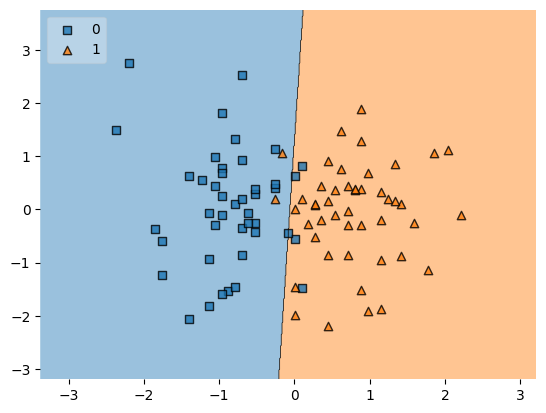

In [27]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend = 2)

In [28]:
import pickle

In [29]:
pickle.dump(clf, open('model.pkl', 'wb'))